# 03 — Exploratory Analysis

**Objective** — use a small set of views to understand the target distribution and useful associations.

**Input** — cleaned analytical dataset.

**Output** — evidence that supports the modeling choices used later.

## 1. Target Distribution

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

current_directory = Path.cwd().resolve()
project_root = next(
    directory for directory in [current_directory, *current_directory.parents]
    if (directory / 'src').is_dir() and (directory / 'notebooks').is_dir()
)
processed_data_path = project_root / 'data' / 'processed' / 'analytical_dataset.csv'
analytical_dataset = pd.read_csv(processed_data_path)
analytical_dataset['charges'].describe(percentiles=[.5, .75, .9, .95, .99])

count     2343.000000
mean     13559.067870
std      11922.658415
min        563.840000
50%       9634.540000
75%      17029.675000
90%      34801.100000
95%      39716.781000
99%      47179.835600
max      63770.430000
Name: charges, dtype: float64

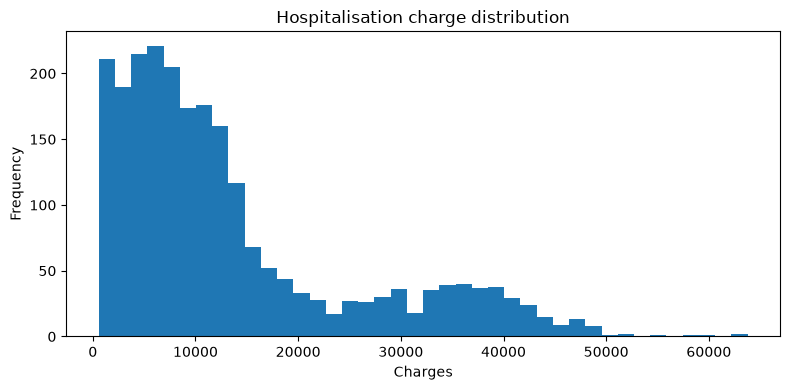

In [2]:
charge_histogram = analytical_dataset['charges'].plot.hist(
    bins=40, figsize=(8, 4), title='Hospitalisation charge distribution'
)
charge_histogram.set_xlabel('Charges')
plt.tight_layout()

## 2. Example Feature Relationship

In [3]:
analytical_dataset.groupby('smoker', dropna=False)['charges'].agg(['count', 'median', 'mean']).round(2)

,count,median,mean
smoker,,,
No,1845,7531.70,8394.93
Yes,488,34185.67,32931.41
NaN,10,19323.61,20971.87


## Takeaways

Charges are strongly right-skewed. This supports MAE as the main regression metric and motivates a separate high-cost classification task. The relationships shown here are associations, not causal conclusions.